# Engineering of Data Analysis - lecture 3

Engineering of Data Analysis is an elective course of the MSc in Business Analytics of NOVA SBE. The course assumes knowledge of Python programming language and Pandas framework.

This notebook presents examples and exercises of lecture 3, focusing on high-performance data analysis.

**IMPORTANT:** To use GPUs in Colab, you need to go to the menu ```Edit > Notebook settings``` and select GPU as the hardware accelerator.

**Using runtimes with GPUs is free, but Colab limits the amount of time you run a runtime with a GPUs. Make sure that you stop the runtime when not using it. I suggest that while developing, developr the code first in the CPU version.**

Some useful links:
* [CuPy documentation](https://docs.cupy.dev/en/stable/)
* [CuDF documentation](https://docs.rapids.ai/api/cudf/stable/)
* [cuML documentation](https://docs.rapids.ai/api/cuml/stable/)


# Setup



In [ ]:
# Hardware configuration
!echo '=== CPU ==='
!lscpu | grep -E 'Model name|Socket|Core|Thread|MHz'
!echo
!echo '=== Memory ==='
!free -h
!echo
!echo '=== GPU ==='
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv,noheader


=== CPU ===
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
Thread(s) per core:                      2
Core(s) per socket:                      1
Socket(s):                               1

=== Memory ===
               total        used        free      shared  buff/cache   available
Mem:            12Gi       714Mi       8.5Gi       2.0Mi       3.4Gi        11Gi
Swap:             0B          0B          0B

=== GPU ===
Tesla T4, 15360 MiB, 7.5


Next cells setup: Pandas and cuDF/cuML.

In [1]:
# General imports
import timeit

import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn.cluster


In [2]:
# Imports for cuDF / cuML

import cudf
import cupy as cp
import cuml.cluster

## CuPy examples

CuPy provides a NumPy-compatible API that runs on the GPU. We compare GPU (CuPy) vs CPU (NumPy) performance for two operations — array sum and matrix multiplication — across a range of data sizes.

### Simple array sum

We start with a 1-D array sum using CuPy on the GPU.

In [ ]:
import cupy as cp
import numpy as np

size = 200_000_000
x_gpu = cp.random.rand(size).astype('f')

In [ ]:
%%timeit
x_gpu.sum()
cp.cuda.Stream.null.synchronize()

3.07 ms ± 34.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


And now the same sum using NumPy on the CPU.

In [ ]:
x_cpu = np.random.rand(size).astype('f')

In [ ]:
%%timeit
x_cpu.sum()

85.6 ms ± 21.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
del x_gpu, x_cpu

### Simple matrix multiplication

Now matrix multiplication using CuPy on the GPU.

In [ ]:
size = 3000
x_gpu = cp.random.rand(size, size).astype('f')
y_gpu = cp.random.rand(size, size).astype('f')

In [ ]:
%%timeit
x_gpu @ y_gpu
cp.cuda.Stream.null.synchronize()

13.4 ms ± 99.2 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


And now using NumPy on the CPU.

In [ ]:
x_cpu = np.random.rand(size, size).astype('f')
y_cpu = np.random.rand(size, size).astype('f')

In [ ]:
%%timeit
x_cpu @ y_cpu

502 ms ± 30.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
del x_gpu, y_gpu, x_cpu, y_cpu

### Array sum: does data size matter?

We time a 1-D array sum on CPU and GPU for increasing array sizes. Because this operation is **memory-bandwidth-bound** (it just reads each element once and adds it), the GPU advantage is modest: both CPU and GPU are limited by how fast they can stream data from memory.

In [ ]:
import cupy as cp
import numpy as np
import timeit
import pandas as pd

sizes = [10**4, 10**5, 10**6, 10**7, 10**8]
results_sum = []

for n in sizes:
    x_cpu = np.random.rand(n).astype('f')
    x_gpu = cp.array(x_cpu)

    t_cpu = timeit.timeit(lambda: x_cpu.sum(), number=20) / 20

    # Warm up GPU (first call has JIT overhead)
    x_gpu.sum(); cp.cuda.Stream.null.synchronize()
    t_gpu = timeit.timeit(
        lambda: (x_gpu.sum(), cp.cuda.Stream.null.synchronize()),
        number=20) / 20

    results_sum.append({'size': n, 'CPU (s)': t_cpu, 'GPU (s)': t_gpu,
                        'speedup': t_cpu / t_gpu})
    del x_cpu, x_gpu

df_sum = pd.DataFrame(results_sum)
df_sum['size'] = df_sum['size'].apply(lambda x: f'{x:,.0f}')
print(df_sum.to_string(index=False, float_format='{:.4f}'.format))

       size  CPU (s)  GPU (s)  speedup
     10,000   0.0000   0.0001   0.1253
    100,000   0.0001   0.0001   0.6704
  1,000,000   0.0006   0.0001   7.8335
 10,000,000   0.0033   0.0002  15.1523
100,000,000   0.0353   0.0016  22.5389


### What do these results tell us? (array sum)

The GPU speedup for array sum **grows with data size**, but the GPU is actually **slower than the CPU for small arrays** (< ~500K elements):

| Array size | Speedup |
|---|---|
| 10,000 | 0.13× — GPU is 8× **slower** |
| 100,000 | 0.67× — GPU still slower |
| 1,000,000 | 7.8× — GPU faster |
| 10,000,000 | 15× |
| 100,000,000 | 22× |

For small arrays, the fixed cost of launching a GPU kernel dominates. At 200M elements (the simple example above) we observed ~28× speedup, consistent with this trend.

This operation is **memory-bandwidth-bound** — it reads each element once and adds it. The GPU wins at large sizes because it has much higher memory bandwidth than the CPU, but the advantage is capped (unlike compute-bound operations).

### Matrix multiplication: GPU advantage grows with size

Matrix multiplication is **compute-bound**: for an `N×N` matrix, it does O(N³) operations on O(N²) data. This high arithmetic intensity is exactly where GPUs shine — their thousands of cores can all work in parallel. We expect the GPU speedup to be small for tiny matrices (kernel launch overhead dominates) and large for big matrices.

In [ ]:
sizes = [64, 256, 512, 1024, 2048, 4096]
results_matmul = []

for n in sizes:
    x_cpu = np.random.rand(n, n).astype('f')
    y_cpu = np.random.rand(n, n).astype('f')
    x_gpu = cp.array(x_cpu)
    y_gpu = cp.array(y_cpu)

    t_cpu = timeit.timeit(lambda: x_cpu @ y_cpu, number=5) / 5

    # Warm up
    x_gpu @ y_gpu; cp.cuda.Stream.null.synchronize()
    t_gpu = timeit.timeit(
        lambda: (x_gpu @ y_gpu, cp.cuda.Stream.null.synchronize()),
        number=5) / 5

    results_matmul.append({'size (N×N)': f'{n}×{n}',
                           'CPU (s)': t_cpu, 'GPU (s)': t_gpu,
                           'speedup': t_cpu / t_gpu})
    del x_cpu, y_cpu, x_gpu, y_gpu

df_matmul = pd.DataFrame(results_matmul)
print(df_matmul.to_string(index=False, float_format='{:.4f}'.format))

size (N×N)  CPU (s)  GPU (s)  speedup
     64×64   0.0000   0.0001   0.2287
   256×256   0.0004   0.0002   2.4369
   512×512   0.0027   0.0002  12.4556
 1024×1024   0.0196   0.0012  16.8929
 2048×2048   0.1659   0.0064  26.0199
 4096×4096   1.5822   0.0382  41.3744


### What do these results tell us? (matrix multiplication)

| Matrix size | Speedup | Behaviour |
|---|---|---|
| 64×64 | 0.23× | GPU is **4× slower** — kernel launch overhead dominates |
| 256×256 | 2.4× | GPU starts to pull ahead |
| 512×512 | 12× | GPU clearly faster |
| 1024×1024 | 17× | Large speedup |
| 2048×2048 | 26× | Very large speedup |
| 4096×4096 | **41×** | GPU is ~41× faster |

Matrix multiplication does O(N³) operations on O(N²) data — very high arithmetic intensity. At 3000×3000 (the simple example above) we observed ~37×, consistent with this trend.

The GPU advantage **keeps growing with N** because all cores stay fully occupied. This is the ideal workload for GPU acceleration: small matrices waste GPU capacity, large matrices exploit it fully.

### Data transfer: the hidden cost of GPU computing

Before the GPU can process data, it must be **copied from main (CPU) memory to GPU memory** over the PCIe bus. This transfer has a fixed bandwidth limit (typically 10–16 GB/s on PCIe 3.0, vs ~900 GB/s for GPU internal memory). For small datasets, this transfer cost can exceed the time saved by GPU computation.

We measure the transfer time with `cp.array()` (CPU → GPU) and `cp.asnumpy()` (GPU → CPU) across a range of array sizes, and compare it to the time saved by computing on the GPU.

In [ ]:
import cupy as cp
import numpy as np
import timeit
import pandas as pd

sizes = [10**4, 10**5, 10**6, 10**7, 10**8]
results_transfer = []

for n in sizes:
    x_cpu = np.random.rand(n).astype('f')  # float32: 4 bytes per element
    x_gpu = cp.array(x_cpu)                # warm-up transfer
    cp.cuda.Stream.null.synchronize()

    # Time CPU→GPU transfer
    t_h2d = timeit.timeit(
        lambda: (cp.array(x_cpu), cp.cuda.Stream.null.synchronize()),
        number=10) / 10

    # Time GPU→CPU transfer
    t_d2h = timeit.timeit(
        lambda: (cp.asnumpy(x_gpu), cp.cuda.Stream.null.synchronize()),
        number=10) / 10

    # Time the GPU sum (computation only, data already on GPU)
    x_gpu.sum(); cp.cuda.Stream.null.synchronize()
    t_compute = timeit.timeit(
        lambda: (x_gpu.sum(), cp.cuda.Stream.null.synchronize()),
        number=20) / 20

    mb = n * 4 / 1e6  # megabytes
    results_transfer.append({
        'size': n,
        'data (MB)': mb,
        'CPU→GPU (s)': t_h2d,
        'GPU→CPU (s)': t_d2h,
        'compute (s)': t_compute,
        'transfer/compute': (t_h2d + t_d2h) / t_compute,
    })
    del x_gpu

df_transfer = pd.DataFrame(results_transfer)
df_transfer['size'] = df_transfer['size'].apply(lambda x: f'{x:,.0f}')
print(df_transfer.to_string(index=False, float_format='{:.4f}'.format))

       size  data (MB)  CPU→GPU (s)  GPU→CPU (s)  compute (s)  transfer/compute
     10,000     0.0400       0.0003       0.0000       0.0001            5.1043
    100,000     0.4000       0.0001       0.0001       0.0001            5.3016
  1,000,000     4.0000       0.0010       0.0010       0.0001           34.6689
 10,000,000    40.0000       0.0113       0.0153       0.0002          126.9058
100,000,000   400.0000       0.1104       0.1468       0.0016          162.3572


### What do these results tell us? (data transfer)

The `transfer/compute` column shows how many times longer the round-trip data transfer (CPU→GPU + GPU→CPU) takes compared to the GPU computation itself:

| Array size | Data | Transfer time | Compute time | Transfer/Compute |
|---|---|---|---|---|
| 10,000 | 0.04 MB | ~0.03 ms | ~0.10 ms | **5×** |
| 100,000 | 0.4 MB | ~0.02 ms | ~0.10 ms | **5×** |
| 1,000,000 | 4 MB | ~2.0 ms | ~0.10 ms | **35×** |
| 10,000,000 | 40 MB | ~26 ms | ~0.20 ms | **127×** |
| 100,000,000 | 400 MB | ~257 ms | ~1.6 ms | **162×** |

For an array sum, the transfer cost **always dominates** — by 5× to 162×. This means that if you had to transfer data to the GPU just to compute a sum and transfer it back, you would be far better off staying on the CPU.

This is why GPU frameworks like cuDF keep data **resident in GPU memory** across operations: load once with `cudf.read_csv()`, then all subsequent groupby, rolling, join operations run on the GPU without repeated transfers. The transfer cost is paid once, not once per operation.

### Data transfer vs. computation: does arithmetic intensity matter?

The previous experiment showed that for an array sum (low arithmetic intensity), transfer cost always dominates. Now we repeat the same measurement for **matrix multiplication** (high arithmetic intensity: O(N³) operations on O(N²) data) to see whether the picture changes.

In [5]:
sizes_mat = [64, 512, 2048, 8192]
results_transfer_mat = []

for n in sizes_mat:
    x_cpu = np.random.rand(n, n).astype('f')
    y_cpu = np.random.rand(n, n).astype('f')
    x_gpu = cp.array(x_cpu)  # warm-up
    y_gpu = cp.array(y_cpu)
    cp.cuda.Stream.null.synchronize()

    # Time CPU→GPU transfer (both matrices)
    t_h2d = timeit.timeit(
        lambda: (cp.array(x_cpu), cp.array(y_cpu), cp.cuda.Stream.null.synchronize()),
        number=10) / 10

    # Time GPU→CPU transfer (result matrix)
    z_gpu = x_gpu @ y_gpu
    t_d2h = timeit.timeit(
        lambda: (cp.asnumpy(z_gpu), cp.cuda.Stream.null.synchronize()),
        number=10) / 10

    # Time GPU matmul (data already on GPU)
    x_gpu @ y_gpu; cp.cuda.Stream.null.synchronize()
    t_compute = timeit.timeit(
        lambda: (x_gpu @ y_gpu, cp.cuda.Stream.null.synchronize()),
        number=10) / 10

    mb = 3 * n * n * 4 / 1e6  # 2 input + 1 output matrices, float32
    results_transfer_mat.append({
        'size (N×N)': f'{n}×{n}',
        'data (MB)': mb,
        'CPU→GPU (s)': t_h2d,
        'GPU→CPU (s)': t_d2h,
        'compute (s)': t_compute,
        'transfer/compute': (t_h2d + t_d2h) / t_compute,
    })
    del x_gpu, y_gpu, z_gpu

df_transfer_mat = pd.DataFrame(results_transfer_mat)
print(df_transfer_mat.to_string(index=False, float_format='{:.4f}'.format))

size (N×N)  data (MB)  CPU→GPU (s)  GPU→CPU (s)  compute (s)  transfer/compute
     64×64     0.0492       0.0008       0.0000       0.0003            2.7711
   512×512     3.1457       0.0017       0.0008       0.0007            3.7013
 2048×2048    50.3316       0.0271       0.0050       0.0070            4.5805
 8192×8192   805.3064       0.1269       0.1212       0.2536            0.9784


### What do these results tell us? (transfer vs. matmul)

| Matrix size | Data | Transfer | Compute | Transfer/Compute |
|---|---|---|---|---|
| 64×64 | 0.05 MB | ~0.8 ms | ~0.3 ms | **2.8×** |
| 512×512 | 3 MB | ~2.5 ms | ~0.7 ms | **3.7×** |
| 2048×2048 | 50 MB | ~32 ms | ~7 ms | **4.6×** |
| 8192×8192 | 805 MB | ~249 ms | ~254 ms | **0.98×** |

Compare this with the array sum experiment, where the ratio reached ~160× — for matrix multiplication it stays much lower (around 3–5× for mid sizes) and eventually drops to ~1× at 8192×8192, where transfer and compute take roughly the same amount of time.

The key difference is **arithmetic intensity**: matrix multiplication does O(N³) operations on O(N²) data, so each byte transferred gets reused many times during the computation. As N grows, the compute work grows faster than the data volume, shifting the balance away from transfer.

**Takeaways:**
- For low-intensity operations (sum, simple aggregations), transfer always dominates → keep data resident on the GPU across operations.
- For high-intensity operations (matmul, deep learning, many ML algorithms), compute eventually catches up with transfer → the one-time transfer cost is justified.
- This is why GPUs revolutionised deep learning: training loops do thousands of matrix multiplications on the same data, amortising the transfer cost over millions of operations.

### GPU memory access patterns

Just like CPUs have caches, GPUs have local memory — and data must be copied from main (CPU) memory to GPU memory before the GPU can use it. Once in GPU memory, *how* threads access that memory has a large impact on performance.

**Coalesced vs. non-coalesced access**

A GPU executes threads in groups called *warps* (typically 32 threads). When all threads in a warp access consecutive memory addresses, the GPU can satisfy all 32 reads in a single memory transaction — this is called **coalesced access**. When threads access strided addresses, each access requires a separate transaction, multiplying the memory bandwidth cost.

This is the GPU equivalent of the cache-line effect we saw in lecture 2:
- CPU: accessing `arraydouble[i][j]` row-by-row kept data in the cache line → fast
- GPU: threads accessing consecutive addresses → coalesced → fast

The following experiment shows this using a large 2D matrix and summing along different axes.

In [ ]:
# Large matrix stored in row-major order (C order, the default)
# Rows are contiguous in GPU memory
rows, cols = 10000, 10000
mat_gpu = cp.random.rand(rows, cols, dtype=cp.float32)

In [ ]:
%%timeit
# Coalesced: sum along axis=1 (across columns within each row)
# Each warp processes one row — threads read consecutive addresses
result = mat_gpu.sum(axis=1)
cp.cuda.Stream.null.synchronize()  # wait for GPU to finish before timing

1.58 ms ± 22.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
%%timeit
# Non-coalesced: sum along axis=0 (across rows within each column)
# Each warp processes one column — threads read addresses 10000 elements apart
result = mat_gpu.sum(axis=0)
cp.cuda.Stream.null.synchronize()

2.19 ms ± 9.19 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### What do these results tell us?

Both operations sum the same 100 million values — the only difference is the axis.

| Operation | Access pattern | Observed time |
|---|---|---|
| `mat_gpu.sum(axis=1)` — across columns | **Coalesced** (consecutive addresses) | 1.58 ms |
| `mat_gpu.sum(axis=0)` — across rows | **Non-coalesced** (stride = 10 000 elements) | 2.19 ms |

The non-coalesced access is ~1.4× slower. The difference is noticeable but modest — CuPy's reduction kernels use shared memory tiling to partially mitigate non-coalesced access. In raw CUDA code without such optimisations, the penalty is typically 5–10×.

This is the GPU equivalent of the cache-line effect from lecture 2 (`arraydouble` row-major vs column-major): **access locality determines performance** at every level of the memory hierarchy.

In [ ]:
del mat_gpu

## cuDF examples

Simple statistics with a small dataset from rapids installation.

First using cuDF.

In [ ]:
fileName = os.path.join( "sample_data", "california_housing_train.csv")

# Read a CSV file into a DataFrame
df_gpu = cudf.read_csv(fileName)


In [ ]:
%%timeit

df_gpu[["housing_median_age", "median_house_value"]].groupby(["housing_median_age"]).mean()
cp.cuda.Stream.null.synchronize()

1.08 ms ± 112 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


And now using simple Pandas.

In [ ]:
fileName = os.path.join( "sample_data", "california_housing_train.csv")

# Read a CSV file into a DataFrame
df_cpu = pd.read_csv(fileName)


In [ ]:
%%timeit

df_cpu[["housing_median_age", "median_house_value"]].groupby(["housing_median_age"]).mean()

1.59 ms ± 237 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


Now a slightly more complex computation — a rolling window sum.

The California housing dataset has ~17,000 rows. With this small dataset the GPU advantage is already visible: ~1.5× for groupby, ~2.8× for rolling. The gap would be much larger on a dataset with millions of rows, as the CuPy scaling experiments showed.

In [ ]:
%%timeit

df_gpu[["housing_median_age","median_house_value"]].rolling(window=3).sum()
cp.cuda.Stream.null.synchronize()

567 µs ± 8.68 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [ ]:
%%timeit

df_cpu[["housing_median_age","median_house_value"]].rolling(window=3).sum()

1.57 ms ± 325 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## cuML examples

KMeans clustering on the California housing dataset (`sample_data/california_housing_train.csv`), using `latitude` and `longitude` as features. We cluster into 50 groups, which correspond roughly to geographic regions of California.

First using cuML on the GPU.

In [ ]:
fileName = os.path.join('sample_data', 'california_housing_train.csv')
dataset_gpu = cudf.read_csv(fileName)[['latitude', 'longitude']]

In [ ]:
%%timeit
model_gpu = cuml.cluster.KMeans(n_clusters=50, max_iter=300, init='k-means++')
model_gpu.fit(dataset_gpu)
cp.cuda.Stream.null.synchronize()

46 ms ± 14.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [ ]:
model_gpu = cuml.cluster.KMeans(n_clusters=50, max_iter=300, init='k-means++')
model_gpu.fit(dataset_gpu)

KMeans()

In [ ]:
%%timeit
labels_gpu = model_gpu.predict(dataset_gpu)
cp.cuda.Stream.null.synchronize()

2.08 ms ± 161 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


And now using scikit-learn on the CPU.

In [ ]:
fileName = os.path.join('sample_data', 'california_housing_train.csv')
dataset_cpu = pd.read_csv(fileName)[['latitude', 'longitude']]

In [ ]:
%%timeit
model_cpu = sklearn.cluster.KMeans(n_clusters=50, max_iter=300, init='k-means++')
model_cpu.fit(dataset_cpu)

102 ms ± 1.92 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
model_cpu = sklearn.cluster.KMeans(n_clusters=50, max_iter=300, init='k-means++')
model_cpu.fit(dataset_cpu)

KMeans(n_clusters=50)

In [ ]:
%%timeit
labels_cpu = model_cpu.predict(dataset_cpu)

4.27 ms ± 499 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### What do these results tell us? (cuML vs scikit-learn)

| Operation | GPU (cuML) | CPU (sklearn) | Speedup |
|---|---|---|---|
| KMeans fit (k=50, 17K points) | 46 ms | 102 ms | **2.2×** |
| KMeans predict | 2.1 ms | 4.3 ms | **2.1×** |

With 17,000 points and 50 clusters, both fit and predict are faster on the GPU. The speedup (~2×) is modest compared to matrix multiplication (~40×), because KMeans has lower arithmetic intensity: most of the work is computing distances (one pass over the data per iteration) rather than dense matrix operations.

For truly large datasets (hundreds of thousands of points or more) the GPU advantage would be much larger — the compute time grows with N while kernel launch overhead stays fixed.

### Visualisation

The cell below plots the cluster assignments as a scatter plot. Each point is a census block coloured by its cluster — the result should look like a map of California divided into geographic regions.

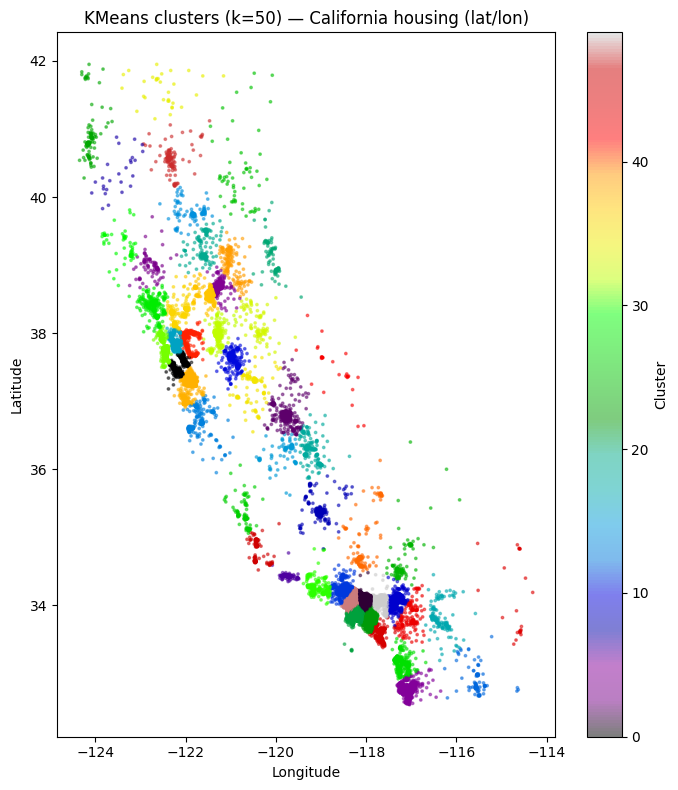

In [ ]:
# Visualisation of cluster assignments
labels = model_gpu.predict(dataset_gpu).to_numpy()
df_plot = dataset_cpu.copy()
df_plot['cluster'] = labels

plt.figure(figsize=(7, 8))
plt.scatter(df_plot['longitude'], df_plot['latitude'],
            c=df_plot['cluster'], cmap='nipy_spectral', s=3, alpha=0.5)
plt.title('KMeans clusters (k=50) — California housing (lat/lon)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
!ls -la sample_data

total 55512
drwxr-xr-x 1 root root     4096 Mar 30 13:34 .
drwxr-xr-x 1 root root     4096 Mar 30 13:34 ..
-rwxr-xr-x 1 root root     1697 Jan  1  2000 anscombe.json
-rw-r--r-- 1 root root   301141 Mar 30 13:34 california_housing_test.csv
-rw-r--r-- 1 root root  1706430 Mar 30 13:34 california_housing_train.csv
-rw-r--r-- 1 root root 18289443 Mar 30 13:34 mnist_test.csv
-rw-r--r-- 1 root root 36523880 Mar 30 13:34 mnist_train_small.csv
-rwxr-xr-x 1 root root      962 Jan  1  2000 README.md


In [ ]:
!cat sample_data/README.md

This directory includes a few sample datasets to get you started.

*   `california_housing_data*.csv` is California housing data from the 1990 US
    Census; more information is available at:
    https://docs.google.com/document/d/e/2PACX-1vRhYtsvc5eOR2FWNCwaBiKL6suIOrxJig8LcSBbmCbyYsayia_DvPOOBlXZ4CAlQ5nlDD8kTaIDRwrN/pub

*   `mnist_*.csv` is a small sample of the
    [MNIST database](https://en.wikipedia.org/wiki/MNIST_database), which is
    described at: http://yann.lecun.com/exdb/mnist/

*   `anscombe.json` contains a copy of
    [Anscombe's quartet](https://en.wikipedia.org/wiki/Anscombe%27s_quartet); it
    was originally described in

    Anscombe, F. J. (1973). 'Graphs in Statistical Analysis'. American
    Statistician. 27 (1): 17-21. JSTOR 2682899.

    and our copy was prepared by the
    [vega_datasets library](https://github.com/altair-viz/vega_datasets/blob/4f67bdaad10f45e3549984e17e1b3088c731503d/vega_datasets/_data/anscombe.json).
